# Exploration du marché data France

Notebook d'exploration sur l'état actuel de `fct_offre` et des marts associés
(552 offres, extraction du 17/07/2026). Pas d'historique temporel disponible 
(`fct_marche_hebdo` n'existe pas encore) donc cette exploration porte sur un
instantané, pas une évolution.

In [2]:
import duckdb

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

con.execute("select count(*) from fct_offre").fetchone()

(552,)

## 1. Vue d'ensemble

In [3]:
con.execute("""
select
    type_contrat,
    count(offre_id) as nb_offres,
    round((count(offre_id) / sum(count(offre_id)) over ()) * 100, 2) as pc_offres
from fct_offre
group by type_contrat
order by nb_offres desc""").df()

,type_contrat,nb_offres,pc_offres
0,CDI,395,71.56
1,CDD,89,16.12
2,MIS,58,10.51
3,LIB,9,1.63
4,CCE,1,0.18


CDI et CDD concentrent 484/552 offres (87,7 %). `CCE` n'a qu'une seule offre.

In [4]:
con.execute("""
select
    experience_exige,
    count(offre_id) as nb_offres,
    round((count(offre_id) / sum(count(offre_id)) over ()) * 100, 2) as pc_offres
from fct_offre
group by experience_exige
order by nb_offres desc""").df()

,experience_exige,nb_offres,pc_offres
0,E,304,55.07
1,D,248,44.93


In [5]:
con.execute("""
select
    distinct experience_exige
from stg_ft_offres
""").df()

,experience_exige
0,E
1,D


D = débutant accepté, E = expérience exigée (convention API France Travail).
Aucun "S" (expérience souhaitée) sur ce périmètre.

In [6]:
con.execute("""
select
    categorie_employeur, 
    count(offre_id) as nb_offres,
    round((count(offre_id) / sum(count(offre_id)) over ()) * 100.0, 2) as pc_offres
from fct_offre
group by categorie_employeur
order by nb_offres desc
""").df()

,categorie_employeur,nb_offres,pc_offres
0,EMPLOYEUR_DIRECT,213,38.59
1,ANONYME,187,33.88
2,INTERMEDIAIRE,131,23.73
3,INTERMEDIAIRE_reclasse,21,3.80


EMPLOYEUR_DIRECT (38,6 %) est la première catégorie mais reste minoritaire dans
l'absolu : ANONYME (33,9 %) et INTERMEDIAIRE + INTERMEDIAIRE_reclasse (27,5 %
cumulés) pèsent presque autant. Seule EMPLOYEUR_DIRECT est éligible au
matching DINUM (80,3 % de taux de matching sur ces 213 offres).
Les deux tiers du périmètre restent donc hors de portée de l'enrichissement
SIRENE actuel.

### Distribution temporelle des offres (date_creation)

À ne pas confondre avec `dim_entreprise.date_creation` (date de création de
l'entreprise) : ici `date_creation` sur `fct_offre` est la date de
publication de l'offre. Le dump étant un pull ponctuel (17/07/2026), on ne
lit pas une tendance ici mais l'étendue temporelle des offres actives au
moment du pull, utile pour situer la fraîcheur des 552 offres.

In [7]:
con.execute("""
select
    min(date_creation) as offre_plus_ancienne,
    max(date_creation) as offre_plus_recente,
    date_diff('day', min(date_creation), max(date_creation)) as etendue_jours,
    count(offre_id) as nb_offres
from fct_offre
""").df()

,offre_plus_ancienne,offre_plus_recente,etendue_jours,nb_offres
0,2025-05-21 03:49:47,2026-07-17 12:10:57,422,552


Étendue de 422 jours, bien plus large qu'un simple "instantané récent" :
l'offre la plus ancienne date de mai 2025, plus d'un an avant le pull. Une
offre encore active à cette ancienneté est probablement une offre à
recrutement continu ou difficile à pourvoir, pas représentative d'un flux
hebdomadaire normal. Un histogramme par mois permet de voir si la majorité
des 552 offres est récente avec une longue traîne, ou si la distribution est
plus étalée.

In [8]:
con.execute("""
select
    date_trunc('month', date_creation) as mois,
    count(offre_id) as nb_offres
from fct_offre
group by mois
order by mois
""").df()

,mois,nb_offres
0,2025-05-01,1
1,2025-06-01,1
2,2025-07-01,1
3,2026-01-01,2
4,2026-02-01,8
5,2026-03-01,4
6,2026-04-01,30
7,2026-05-01,40
8,2026-06-01,170
9,2026-07-01,295


La distribution confirme la première lecture : 465/552 offres (84,2 %) sont
publiées en juin ou juillet 2026, les deux mois précédant le pull. Croissance
progressive de janvier (2) à juillet (295), cohérente avec une accumulation
normale d'offres actives sur un marché qui recrute en continu.

Les 3 offres de 2025 (mai, juin, juillet) sont des outliers isolés : plus de
6 mois d'écart avec la reprise en janvier 2026, aucune offre entre les deux.
Trois cas exceptionnels (recrutement difficile ou continu), pas un signal
de fond. Non traités (volume trop faible pour une règle), mais désormais
documentés plutôt que silencieusement ignorés.

## 2. Compétences demandées

`fct_offre_technologie` et `fct_offre_domaine` ont un grain plus fin que
`fct_offre` : une ligne = un couple (offre, terme). `count(distinct offre_id)`
systématique pour éviter tout surcomptage.

In [9]:
con.execute("""
select
    technologie,
    count(distinct offre_id) as nb_offres,
    rank() over (order by count(distinct offre_id) desc)
from fct_offre_technologie
group by technologie
order by nb_offres desc
limit 10
""").df()

,technologie,nb_offres,rank() OVER (ORDER BY count(DISTINCT offre_id) DESC)
0,Python,152,1
1,SQL,148,2
2,Power BI,104,3
3,AWS,32,4
4,Databricks,31,5
5,Git,27,6
6,Tableau,26,7
7,Azure,26,7
8,Snowflake,25,9
9,Spark,24,10


Python et SQL dominent largement (152 et 148 offres, ~27 % chacune), suivis
par Power BI (104, 18,8 %) : le socle langage/requêtage/restitution attendu
sur ces métiers. Le reste du top 10 (AWS, Databricks, Git, Tableau, Azure,
Snowflake, Spark) plafonne sous les 6 % : marché encore peu consolidé sur les
outils cloud/data engineering une fois sorti de ce socle.

### Le stack technique diffère-t-il selon le niveau d'expérience exigé ?

Les offres E (expérience exigée) mentionnent-elles des technologies
différentes — ou plus nombreuses — que les offres D (débutant accepté) ?

In [10]:
con.execute("""
select
    o.experience_exige,
    t.technologie,
    count(distinct o.offre_id) as nb_offres,
    round(100.0 * count(distinct o.offre_id)
        / sum(count(distinct o.offre_id)) over (partition by o.experience_exige), 2) as pc_dans_groupe
from fct_offre o
join fct_offre_technologie t on t.offre_id = o.offre_id
where t.technologie in ('Python', 'SQL', 'Power BI', 'AWS', 'Databricks')
group by o.experience_exige, t.technologie
order by o.experience_exige, nb_offres desc
""").df()

,experience_exige,technologie,nb_offres,pc_dans_groupe
0,D,Python,53,33.54
1,D,Power BI,47,29.75
2,D,SQL,43,27.22
3,D,AWS,9,5.70
4,D,Databricks,6,3.80
5,E,SQL,105,33.98
6,E,Python,99,32.04
7,E,Power BI,57,18.45
8,E,Databricks,25,8.09
9,E,AWS,23,7.44


Python est stable d'un niveau d'expérience à l'autre (33,54 % en D, 32,04 %
en E) : sa prépondérance n'est pas un effet de volume, c'est une vraie
constante du marché, débutant comme confirmé. SQL, en revanche, gagne du
poids relatif avec l'expérience exigée (27,22 % en D → 33,98 % en E) et prend
la première place côté E. Power BI perd près d'un tiers de son poids relatif
entre D (29,75 %) et E (18,45 %), cohérent avec l'intuition que Power BI est
davantage associé aux postes d'entrée qu'aux technologies de traitement de
données. AWS et Databricks progressent ensemble avec le niveau d'expérience
exigé, passant d'un poids cumulé de 9,50 % (D) à 15,53 % (E). Toujours une
corrélation observée, pas une causalité démontrée.

In [11]:
con.execute("""
select 
    domaine_normalise,
    count(distinct offre_id) as nb_offres,
    round(count(distinct offre_id) * 100.0 / (select count(*) from fct_offre), 2) as pc_offres
from fct_offre_domaine
group by domaine_normalise
order by nb_offres desc
limit 5
""").df()

,domaine_normalise,nb_offres,pc_offres
0,Gouvernance des données,122,22.10
1,Analyse de données,109,19.75
2,Qualité des données,68,12.32
3,Business Intelligence,67,12.14
4,Machine Learning,66,11.96


Gouvernance des données (22,1 %) et Analyse de données (19,75 %) arrivent en
tête, suivies de près par Qualité des données, Business Intelligence et
Machine Learning (~12 % chacun). À lire avec la réserve déjà documentée :
ce champ est sous-extrait par Nemo sur les annonces de conseil,
donc ces parts sous-estiment probablement le poids réel de ces domaines sur
ce segment d'employeurs.

In [12]:
con.execute("""
select 
    o.categorie_employeur,
    d.domaine_normalise,
    count(distinct o.offre_id) as nb_offres,
    round(count(distinct o.offre_id) * 100.0 / (select count(*) from fct_offre), 2) as pc_offres
from fct_offre_domaine d
join fct_offre o on o.offre_id = d.offre_id
group by o.categorie_employeur, d.domaine_normalise
order by nb_offres desc
limit 10
""").df()

,categorie_employeur,domaine_normalise,nb_offres,pc_offres
0,EMPLOYEUR_DIRECT,Analyse de données,59,10.69
1,EMPLOYEUR_DIRECT,Gouvernance des données,50,9.06
2,ANONYME,Gouvernance des données,41,7.43
3,ANONYME,Analyse de données,33,5.98
4,EMPLOYEUR_DIRECT,Qualité des données,33,5.98
5,EMPLOYEUR_DIRECT,Data Science,30,5.43
6,EMPLOYEUR_DIRECT,Business Intelligence,30,5.43
7,EMPLOYEUR_DIRECT,Machine Learning,29,5.25
8,EMPLOYEUR_DIRECT,ETL,28,5.07
9,INTERMEDIAIRE,Gouvernance des données,26,4.71


EMPLOYEUR_DIRECT domine la plupart des domaines (Analyse
de données 59, Qualité 33, Data Science 30, BI 30, ML 29), sauf sur
Gouvernance des données où ANONYME talonne de près (41 contre 50) : rien qui
contredise la répartition globale du haut de section.

In [13]:
con.execute("""
select
    r.rome_libelle,
    r.rome_code,
    count(distinct o.offre_id) as nb_offres
from fct_offre o
left join dim_rome r on r.rome_code = o.rome_code
group by r.rome_code, r.rome_libelle
order by nb_offres desc
limit 5
""").df()

,rome_libelle,rome_code,nb_offres
0,Data engineer,M1811,158
1,Data scientist,M1405,125
2,Data analyst,M1419,116
3,Architecte base de données,M1868,35
4,Analyste décisionnel - Business Intelligence,M1851,31


Data engineer (158), data scientist (125) et data analyst (116) concentrent à
eux trois 399/552 offres (72,3 %) : cohérent avec le ciblage motsCles du
pipeline qui élargit volontairement au-delà des deux codes ROME ancres
(M1405, M1811) : Architecte base de données (M1868) et Analyste
décisionnel BI (M1851) apparaissent ici via ce filtrage par mots-clés, pas
par code ROME direct.

Comparer catégorie employeur et technologies terme à terme demande un
`cross join` explicite sur les deux dimensions : sans lui, les combinaisons à
zéro offre (ex. INTERMEDIAIRE_reclasse × AWS) disparaissent silencieusement
du résultat au lieu d'afficher 0, ce qui fausserait toute lecture comparative
entre catégories.

In [14]:
con.execute("""
select
    cat.categorie_employeur,
    tech.technologie,
    coalesce(count(distinct o.offre_id), 0) as nb_offres
from (select distinct categorie_employeur from fct_offre) as cat
cross join (select unnest(['Python', 'SQL', 'Power BI', 'AWS', 'Databricks']) as technologie) as tech
left join fct_offre_technologie t on t.technologie = tech.technologie
left join fct_offre o on o.offre_id = t.offre_id and o.categorie_employeur = cat.categorie_employeur
group by cat.categorie_employeur, tech.technologie
order by cat.categorie_employeur, tech.technologie
""").df()

,categorie_employeur,technologie,nb_offres
0,ANONYME,AWS,13
1,ANONYME,Databricks,12
2,ANONYME,Power BI,29
3,ANONYME,Python,53
4,ANONYME,SQL,40
5,EMPLOYEUR_DIRECT,AWS,10
6,EMPLOYEUR_DIRECT,Databricks,8
7,EMPLOYEUR_DIRECT,Power BI,53
8,EMPLOYEUR_DIRECT,Python,66
9,EMPLOYEUR_DIRECT,SQL,82


EMPLOYEUR_DIRECT domine sur les 5 technologies observées, en particulier SQL
(82 offres) et Python (66) : cohérent avec son poids global (38,6 % des
offres, §1). INTERMEDIAIRE_reclasse reste marginal partout (0 sur AWS et
Databricks, 5 au mieux sur Power BI) : avec seulement 21 offres au total dans
cette catégorie, ces zéros ne signalent pas une absence de besoin, juste un
échantillon trop petit pour conclure.

## 3. Rémunération

Restreint aux salaires `salaire_periode = 'annuel'` (152 offres). Les salaires
horaires et mensuels restent hors de toute analyse statistique : échantillon
trop faible pour être défendable (19 et 1 offres, cf. `assert_bornes_salaire_annuel`
et README, limite vérifiée sans changement en Session 7).

In [15]:
con.execute("""
select
    min(salaire_min),
    max(salaire_min),
    avg(salaire_min),
    median(salaire_min)
from fct_offre
where salaire_periode = 'annuel'
""").df()

,min(salaire_min),max(salaire_min),avg(salaire_min),median(salaire_min)
0,15,100000,43955.506579,42000.0


In [16]:
con.execute("""
select 
    count(offre_id)
from fct_offre
where salaire_periode = 'annuel' and salaire_min < 1000
""").df()

,count(offre_id)
0,1


In [17]:
con.execute("""
select
    offre_id
from fct_offre
where salaire_periode = 'annuel' and salaire_min < 1000
""").df()

,offre_id
0,4933945


In [18]:
con.execute("""
select
    salaire_libelle
from stg_ft_offres
where offre_id = '4933945'
""").df()

,salaire_libelle
0,Annuel de 15.0 Euros


In [19]:
con.execute("""
select
    offre_id
from fct_offre
where salaire_min = 100000
""").df()

,offre_id
0,1620026


In [20]:
con.execute("""
select
    salaire_libelle,
    description
from stg_ft_offres
where offre_id = '1620026'
""").df()

,salaire_libelle,description
0,Annuel de 100000.0 Euros à 110000.0 Euros,Lead Solution Architect H/F – CDI – Paris – Ar...


`min(salaire_min) = 15` sur le premier passage : `salaire_libelle` = "Annuel de
15.0 Euros" (offre 4933945) -> coquille de saisie confirmée sur le texte source,
pas une erreur de parsing du pipeline (cf. limite assumée README). Exclue des
statistiques ci-dessous via `offre_id != '4933945'`.

`max(salaire_min) = 100000` vérifié à part : "Lead Solution Architect", plage
100k-110k€, salaire légitime -> conservé.

In [21]:
con.execute("""
select
    min(salaire_min),
    max(salaire_min),
    avg(salaire_min),
    median(salaire_min)
from fct_offre
where salaire_periode = 'annuel' and offre_id != '4933945'
""").df()

,min(salaire_min),max(salaire_min),avg(salaire_min),median(salaire_min)
0,25000,100000,44246.503311,42000.0


Une fois l'offre 4933945 exclue, le salaire minimum annuel s'étale de
25 000 € à 100 000 €, moyenne 44 247 €, médiane 42 000 € : l'écart
moyenne/médiane (+2 247 €) reflète une distribution étirée vers le haut
plutôt que symétrique.

In [22]:
con.execute("""
select
    categorie_employeur,
    count(offre_id) as nb_offres,
    median(salaire_min)
from fct_offre
where salaire_periode = 'annuel' and offre_id != '4933945'
group by categorie_employeur
""").df()

,categorie_employeur,nb_offres,median(salaire_min)
0,EMPLOYEUR_DIRECT,67,42000.0
1,INTERMEDIAIRE_reclasse,2,67500.0
2,INTERMEDIAIRE,63,44000.0
3,ANONYME,19,40000.0


INTERMEDIAIRE_reclasse affiche la médiane la plus haute (67 500 €) mais
seulement 2 offres à salaire annuel connu dans cette catégorie,
non interprétable. Sur les catégories à échantillon exploitable (19 à 67
offres), l'écart reste modéré : de 40 000 € (ANONYME) à 44 000 €
(INTERMEDIAIRE), rien qui distingue nettement un canal de recrutement par le
niveau de rémunération affiché.

In [23]:
con.execute("""
select
    case when t.offre_id is not null then 'Mentionne Python' else 'Ne mentionne pas Python' end as groupe,
    count(distinct o.offre_id) as nb_offres,
    round(count(distinct o.offre_id) * 100.0 / (select count(*) from fct_offre where salaire_periode = 'annuel'), 2) as pc_offres,
    median(o.salaire_min) as salaire_median
from fct_offre o
left join fct_offre_technologie t
    on t.offre_id = o.offre_id and t.technologie = 'Python'
where o.salaire_periode = 'annuel' and o.offre_id != '4933945'
group by case when t.offre_id is not null then 'Mentionne Python' else 'Ne mentionne pas Python' end
""").df()

,groupe,nb_offres,pc_offres,salaire_median
0,Mentionne Python,52,34.21,41500.0
1,Ne mentionne pas Python,99,65.13,44000.0


In [24]:
con.execute("""
select
    case when t.offre_id is not null then 'Mentionne SQL' else 'Ne mentionne pas SQL' end as groupe,
    count(distinct o.offre_id) as nb_offres,
    round(count(distinct o.offre_id) * 100.0 / (select count(*) from fct_offre where salaire_periode = 'annuel'), 2) as pc_offres,
    median(o.salaire_min) as salaire_median
from fct_offre o
left join fct_offre_technologie t
    on t.offre_id = o.offre_id and t.technologie = 'SQL'
where o.salaire_periode = 'annuel' and o.offre_id != '4933945'
group by case when t.offre_id is not null then 'Mentionne SQL' else 'Ne mentionne pas SQL' end
""").df()

,groupe,nb_offres,pc_offres,salaire_median
0,Ne mentionne pas SQL,93,61.18,42000.0
1,Mentionne SQL,58,38.16,44500.0


In [25]:
df_comparaison = con.execute("""
with technos as (
    select unnest(['Python', 'SQL']) as technologie
)
select
    tech.technologie,
    median(o.salaire_min) filter (where t.offre_id is not null) as avec,
    median(o.salaire_min) filter (where t.offre_id is null) as sans,
    median(o.salaire_min) filter (where t.offre_id is not null)
        - median(o.salaire_min) filter (where t.offre_id is null) as ecart
from technos tech
cross join fct_offre o
left join fct_offre_technologie t
    on t.offre_id = o.offre_id and t.technologie = tech.technologie
where o.salaire_periode = 'annuel'
    and o.offre_id != '4933945'
group by tech.technologie
order by tech.technologie
""").df()

df_comparaison

,technologie,avec,sans,ecart
0,Python,41500.0,44000.0,-2500.0
1,SQL,44500.0,42000.0,2500.0


Salaire médian selon la présence de la technologie (152 offres, salaire annuel).


In [26]:
con.execute("""
select
    offre_id,
    intitule,
    salaire_min,
    median(salaire_min) over () as salaire_median,
    (salaire_min - median(salaire_min) over ()) as ecart
from fct_offre
where salaire_periode = 'annuel' and offre_id != '4933945'
order by abs(ecart) desc
limit 10
""").df()

,offre_id,intitule,salaire_min,salaire_median,ecart
0,1620026,Lead Solution Architect (H/F),100000,42000.0,58000.0
1,4235947,Data Architect (H/F),75000,42000.0,33000.0
2,4492407,Data analyst (H/F),70000,42000.0,28000.0
3,210HSKT,Master data manager (H/F),70000,42000.0,28000.0
4,4173195,Lead Data Analyst H/F,70000,42000.0,28000.0
5,4708289,Staff Data Scientist - Télétravail H/F,65000,42000.0,23000.0
6,4439254,Actuaire/Data scientist Senior (H/F),65000,42000.0,23000.0
7,209HSQC,Consultant SAP (H/F),65000,42000.0,23000.0
8,2294508,Consultant.e Data Engineer Microsoft Fabric F/...,60000,42000.0,18000.0
9,210FJKM,Senior Data Scientist (H/F),60000,42000.0,18000.0


Les écarts les plus marqués à la médiane sont portés par des intitulés
senior/lead (Lead Solution Architect +58 000 €, Data Architect +33 000 €,
Data analyst / Master data manager / Lead Data Analyst +28 000 € chacun) :
l'écart reflète le niveau du poste affiché, pas une anomalie de saisie à
vérifier comme en §3.1.

### Les intermédiaires sont-ils moins transparents sur le salaire ?

Les offres ANONYME / INTERMEDIAIRE affichent-elles un salaire moins souvent
que les offres EMPLOYEUR_DIRECT ?

In [27]:
con.execute("""
select
    categorie_employeur,
    count(distinct offre_id) as nb_offres_total,
    count(distinct case when salaire_mentionne then offre_id end) as nb_avec_salaire,
    round(100.0 * count(distinct case when salaire_mentionne then offre_id end)
        / count(distinct offre_id), 2) as pc_avec_salaire
from fct_offre
group by categorie_employeur
order by pc_avec_salaire desc
""").df()

,categorie_employeur,nb_offres_total,nb_avec_salaire,pc_avec_salaire
0,INTERMEDIAIRE,131,69,52.67
1,EMPLOYEUR_DIRECT,213,80,37.56
2,INTERMEDIAIRE_reclasse,21,3,14.29
3,ANONYME,187,20,10.70


Résultat qui contredit l'hypothèse de départ. `INTERMEDIAIRE` (52,67 %) est
en réalité *plus* transparent sur le salaire que `EMPLOYEUR_DIRECT` (37,56 %):
l'inverse de ce qu'on attendait. Ce sont `ANONYME` (10,70 %) et
`INTERMEDIAIRE_reclasse` (14,29 %) qui affichent le moins souvent un salaire,
et de loin. Lecture plus juste : la transparence salariale semble corrélée au
niveau général de structuration de l'annonce (un nom d'entreprise identifié,
une fiche complète) plutôt qu'au fait d'être ou non un intermédiaire de
placement. Les agences (`INTERMEDIAIRE`) rédigent des annonces standardisées
et complètes ; les offres `ANONYME`/`INTERMEDIAIRE_reclasse` sont justement
celles où l'information manque déjà ailleurs (nom d'employeur), donc le
salaire manque probablement pour la même raison structurelle, pas par choix
délibéré de le cacher.

### Profil d'entreprise : categorie_entreprise et tranche_effectif sont-elles redondantes ?

Avant de construire deux analyses séparées (salaire par catégorie INSEE,
salaire par tranche d'effectif), on vérifie si les deux variables racontent
la même chose. Si oui, une seule suffit.

In [28]:
con.execute("""
select
    categorie_entreprise,
    tranche_effectif,
    count(distinct siren) as nb_entreprises
from dim_entreprise
group by categorie_entreprise, tranche_effectif
order by categorie_entreprise, tranche_effectif
""").df()

,categorie_entreprise,tranche_effectif,nb_entreprises
0,ETI,01,1
1,ETI,02,1
2,ETI,03,1
3,ETI,11,1
4,ETI,12,3
5,ETI,21,4
6,ETI,22,10
7,ETI,32,12
8,ETI,41,7
9,ETI,42,5


Peu de recoupement entre `categorie_entreprise` et `tranche_effectif` : une
même catégorie INSEE (PME, ETI, GE) couvre des tranches d'effectif très
variées (ETI va de `01` à `51`). Cohérent avec la définition légale, qui se
calcule sur effectif + chiffre d'affaires + bilan au niveau du groupe, pas
sur le seul effectif de l'établissement. Les deux variables ne sont pas
redondantes : on les garde comme deux angles distincts.

Anomalie notée : 5 entreprises ont `categorie_entreprise = None` (distinct
du code `NN`, qui signifie "valeur inconnue mais renseignée"). Exclues des
`group by categorie_entreprise` suivants sans traitement particulier,
volume trop faible pour justifier une règle.

### Salaire médian par categorie_entreprise

In [29]:
con.execute("""
select
    e.categorie_entreprise,
    count(distinct o.offre_id) as nb_offres,
    median(o.salaire_min) as salaire_median
from fct_offre o
join dim_entreprise e on e.siren = o.siren
where o.salaire_periode = 'annuel' and o.offre_id != '4933945'
group by e.categorie_entreprise
order by salaire_median desc
""").df()

,categorie_entreprise,nb_offres,salaire_median
0,None,2,49000.0
1,PME,30,45000.0
2,GE,11,40000.0
3,ETI,21,40000.0


64 offres seulement sur les 152 à salaire annuel connu passent par cette
jointure (seules les offres EMPLOYEUR_DIRECT avec SIREN matché DINUM ont un
`dim_entreprise` associé). Sur cet échantillon restreint, les médianes sont
resserrées : de 40 000 € (GE, ETI) à 45 000 € (PME), écart modeste et
échantillons trop petits (11 à 30 offres par catégorie) pour conclure à une
vraie différence de rémunération selon la taille légale de l'entreprise.
Les 2 offres en `categorie_entreprise = None` ne sont pas interprétables.

### Salaire médian par tranche_effectif

In [30]:
con.execute("""
select
    e.tranche_effectif,
    count(distinct o.offre_id) as nb_offres,
    median(o.salaire_min) as salaire_median
from fct_offre o
join dim_entreprise e on e.siren = o.siren
where o.salaire_periode = 'annuel' and o.offre_id != '4933945'
group by e.tranche_effectif
order by e.tranche_effectif
""").df()

,tranche_effectif,nb_offres,salaire_median
0,01,1,38000.0
1,02,13,50000.0
2,03,2,35000.0
3,11,2,47500.0
4,12,6,42000.0
5,21,5,30000.0
6,22,10,39000.0
7,32,9,40000.0
8,41,4,41000.0
9,42,3,40000.0


14 tranches distinctes sur les mêmes 64 offres jointes à `dim_entreprise` :
la plupart comptent 1 à 6 offres, largement sous le seuil de fiabilité déjà
retenu ailleurs dans ce notebook (5 offres minimum, cf. section Géographie).
Aucune tendance monotone entre taille d'effectif et salaire médian : la
tranche `02` (2-5 salariés) affiche la médiane la plus haute (50 000 €),
la tranche `21` (50-99 salariés) la plus basse (30 000 €). Confirme, sur un
angle différent, le constat déjà fait avec `categorie_entreprise` et avec
`age_annees` (cellule 57) : aucune caractéristique structurelle de
l'entreprise mesurée dans ce projet ne discrimine clairement le niveau de
salaire proposé, sur cet échantillon.

### Salaire médian par secteur d'activité (section_naf)

In [31]:
con.execute("""
select
    e.entreprise_section_naf,
    count(distinct o.offre_id) as nb_offres,
    median(o.salaire_min) as salaire_median
from fct_offre o
join dim_entreprise e on e.siren = o.siren
where o.salaire_periode = 'annuel' and o.offre_id != '4933945'
group by e.entreprise_section_naf
order by nb_offres desc
""").df()

,entreprise_section_naf,nb_offres,salaire_median
0,J,20,50000.0
1,M,11,42000.0
2,C,7,35000.0
3,N,6,40000.0
4,G,4,37500.0
5,I,4,35000.0
6,K,4,42500.0
7,S,2,49000.0
8,P,1,37000.0
9,F,1,30000.0


Premier signal net de cette section : le secteur d'activité (section NAF)
discrimine davantage le salaire que les variables structurelles testées
jusqu'ici (âge, catégorie légale, effectif). Sur les sections à échantillon
exploitable (≥5 offres, seuil déjà retenu) :

- **J - Information et communication** : 50 000 € médian (20 offres,
  le plus gros échantillon des quatre)
- **M - Activités spécialisées, scientifiques et techniques** : 42 000 €
  (11 offres)
- **N - Activités de services administratifs et de soutien** : 40 000 €
  (6 offres)
- **C - Industrie manufacturière** : 35 000 € (7 offres)

Cohérent avec l'intuition : les entreprises du secteur numérique (J) paient
davantage pour des profils data que l'industrie manufacturière (C), où ces
postes sont probablement plus périphériques au cœur de métier. Les 10 autres
sections comptent 1 à 4 offres chacune, non interprétables individuellement.

Lettres NAF (nomenclature INSEE, référence) : J = Information-communication,
M = Activités spécialisées scientifiques et techniques, N = Activités de
services administratifs et de soutien, C = Industrie manufacturière.

## 4. Géographie

In [32]:
con.execute("""
select
    c.nom_commune,
    o.code_postal,
    count(distinct o.offre_id) as nb_offres
from fct_offre o
left join dim_commune c on c.code_postal = o.code_postal
group by o.code_postal, c.nom_commune
order by nb_offres desc
limit 11
""").df()

,nom_commune,code_postal,nb_offres
0,None,None,107
1,Paris,75009,16
2,Courbevoie,92400,15
3,Toulouse,31000,15
4,Lille,59000,14
5,Nantes,44000,13
6,Nanterre,92000,13
7,Beauzelle,31700,11
8,Bordeaux,33000,10
9,Puteaux,92800,8


107/552 offres (19,4 %) n'ont pas de code postal : cohérent avec la limite
documentée dans `dim_commune.sql`.

In [33]:
con.execute("""
select
    c.nom_commune,
    median(o.salaire_min) as salaire_median,
    count(distinct o.offre_id) as nb_offres
from dim_commune c
join fct_offre o on c.code_postal = o.code_postal
where o.salaire_periode = 'annuel' and o.offre_id != '4933945'
group by c.nom_commune
having nb_offres >= 5
order by salaire_median desc
""").df()

,nom_commune,salaire_median,nb_offres
0,Toulouse,46000.0,6
1,Paris,45000.0,13
2,Nantes,38000.0,7
3,Lyon,35000.0,7


Seules 4 communes atteignent le seuil de 5 offres à salaire annuel connu.
Échantillons de 6 à 13 offres chacune : même réserve statistique que les
bornes salariales horaire/mensuel (§3) : indicatif, pas une médiane
défendable à grande confiance. Le classement pourrait changer avec 2-3
offres de plus ou de moins.

## 5. Visualisations

In [34]:
import matplotlib.pyplot as plt

In [35]:
MM = {
    "void": "#0B0C0F", "slate": "#15171C",
    "hairline": "#2A2E37", "hairline_bright": "#3A404C",
    "paper": "#F2F3F5", "paper_muted": "#9BA1AC",
    "blue": "#4C8DFF", "amber": "#FFC24B",
    "vermilion": "#FF6B5A", "green": "#4ADE80",
}

plt.rcParams.update({
    "figure.facecolor": MM["void"],
    "axes.facecolor": MM["slate"],
    "axes.edgecolor": MM["hairline"],
    "axes.labelcolor": MM["paper_muted"],
    "text.color": MM["paper"],
    "xtick.color": MM["paper_muted"],
    "ytick.color": MM["paper_muted"],
})

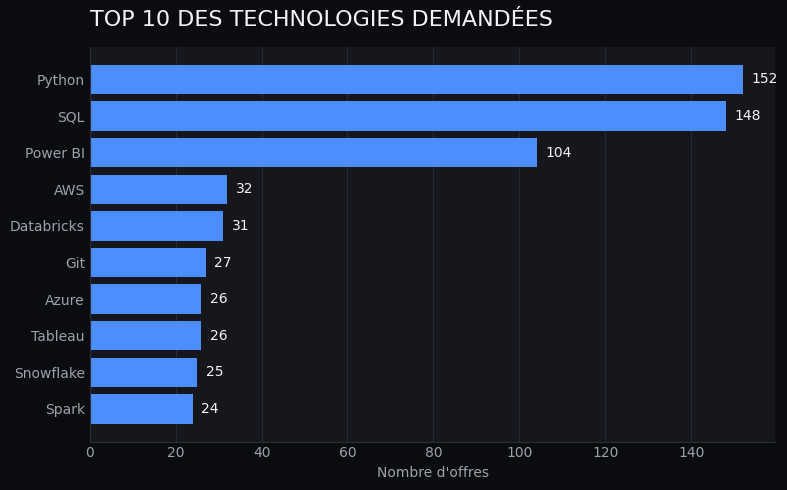

In [36]:
df_top10 = con.execute("""
select technologie, count(distinct offre_id) as nb_offres
from fct_offre_technologie
group by technologie
order by nb_offres desc
limit 10
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(df_top10['technologie'][::-1], df_top10['nb_offres'][::-1], color=MM["blue"])

# Labels directs plutôt qu'un axe chiffré (règle système : "label the data, not a legend")
for bar, valeur in zip(bars, df_top10['nb_offres'][::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2, str(valeur),
            va='center', color=MM["paper"], fontsize=10)

ax.set_title("TOP 10 DES TECHNOLOGIES DEMANDÉES", fontsize=16,
              color=MM["paper"], loc='left', pad=15)
ax.set_xlabel("Nombre d'offres")
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(MM["hairline"])
ax.tick_params(length=0)
ax.grid(axis='x', color=MM["hairline"], linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

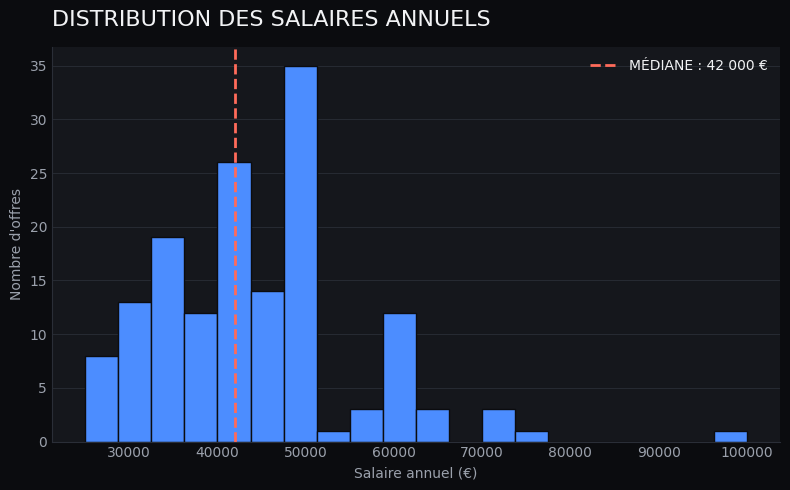

In [37]:
df_salaires = con.execute("""
select salaire_min
from fct_offre
where salaire_periode = 'annuel' and offre_id != '4933945'
""").df()

mediane = df_salaires['salaire_min'].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_salaires['salaire_min'], bins=20, color=MM["blue"], edgecolor=MM["void"])
ax.axvline(mediane, color=MM["vermilion"], linestyle='--', linewidth=2,
           label=f"MÉDIANE : {mediane:,.0f} €".replace(",", " "))

ax.set_title("DISTRIBUTION DES SALAIRES ANNUELS", fontsize=16,
              color=MM["paper"], loc='left', pad=15)
ax.set_xlabel("Salaire annuel (€)")
ax.set_ylabel("Nombre d'offres")
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(MM["hairline"])
ax.tick_params(length=0)
ax.grid(axis='y', color=MM["hairline"], linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, labelcolor=MM["paper"], fontsize=10)
plt.tight_layout()
plt.show()

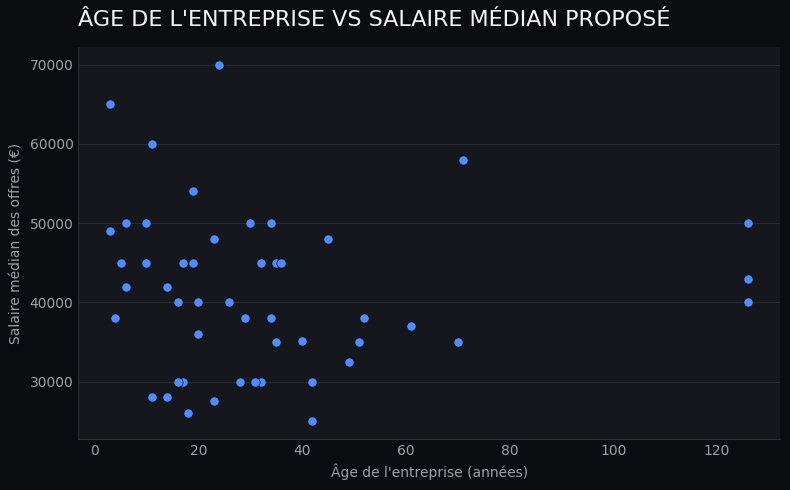

In [38]:
df_age_salaire = con.execute("""
select
    e.siren,
    e.age_annees,
    median(o.salaire_min) as salaire_median
from fct_offre o
join dim_entreprise e on e.siren = o.siren
where o.salaire_periode = 'annuel' and o.offre_id != '4933945'
group by e.siren, e.age_annees
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_age_salaire['age_annees'], df_age_salaire['salaire_median'],
           color=MM["blue"], s=45, edgecolor=MM["void"], linewidth=0.5)

ax.set_title("ÂGE DE L'ENTREPRISE VS SALAIRE MÉDIAN PROPOSÉ", fontsize=16,
              color=MM["paper"], loc='left', pad=15)
ax.set_xlabel("Âge de l'entreprise (années)")
ax.set_ylabel("Salaire médian des offres (€)")
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(MM["hairline"])
ax.tick_params(length=0)
ax.grid(axis='y', color=MM["hairline"], linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Corrélation quasi nulle entre âge de l'entreprise et salaire médian proposé
(r ≈ -0,04 sur 50 entreprises) : aucune tendance visible sur le nuage de
points. Cohérent avec la décision déjà actée de ne pas retenir l'ancienneté
comme variable discriminante dans `dim_entreprise`.

### Répartition des offres par catégorie employeur

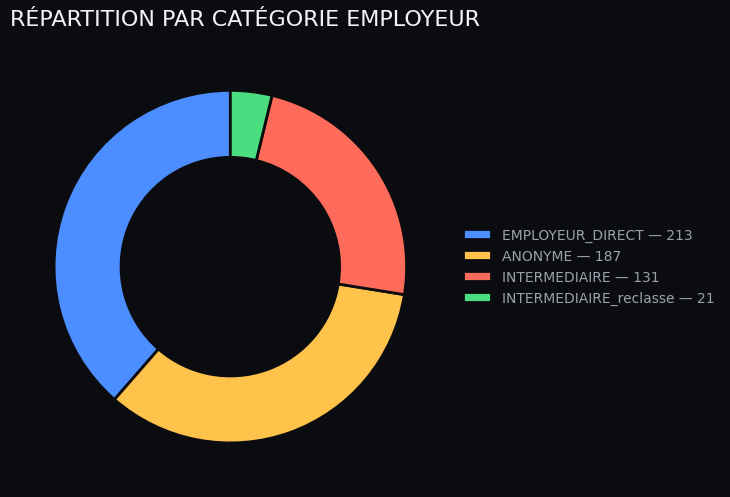

In [39]:
df_cat = con.execute("""
select categorie_employeur, count(offre_id) as nb_offres
from fct_offre
group by categorie_employeur
order by nb_offres desc
""").df()

couleurs = [MM["blue"], MM["amber"], MM["vermilion"], MM["green"]]

fig, ax = plt.subplots(figsize=(7, 6))
resultat_pie = ax.pie(
    df_cat['nb_offres'], colors=couleurs, startangle=90,
    wedgeprops=dict(width=0.38, edgecolor=MM["void"], linewidth=2)
)
wedges = resultat_pie[0]

labels = [f"{cat} — {nb}" for cat, nb in zip(df_cat['categorie_employeur'], df_cat['nb_offres'])]
ax.legend(wedges, labels, loc='center left', bbox_to_anchor=(1, 0.5),
          frameon=False, labelcolor=MM["paper_muted"], fontsize=10)

ax.set_title("RÉPARTITION PAR CATÉGORIE EMPLOYEUR", fontsize=16,
              color=MM["paper"], loc='left', pad=15)
plt.tight_layout()
plt.show()

### Salaire médian selon la mention de Python

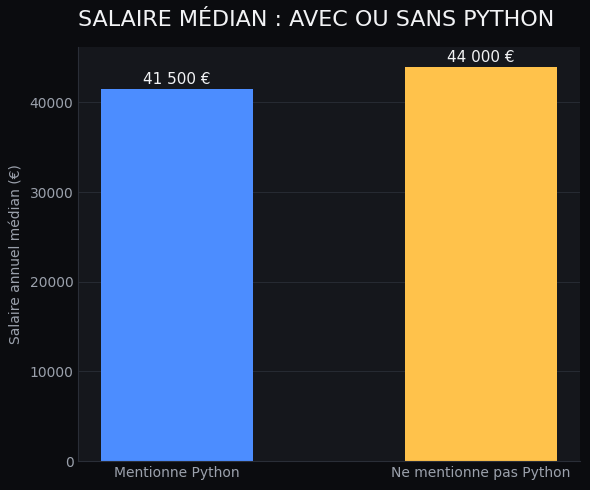

In [40]:
df_python = con.execute("""
select
    case when t.offre_id is not null then 'Mentionne Python' else 'Ne mentionne pas Python' end as groupe,
    median(o.salaire_min) as salaire_median
from fct_offre o
left join fct_offre_technologie t
    on t.offre_id = o.offre_id and t.technologie = 'Python'
where o.salaire_periode = 'annuel' and o.offre_id != '4933945'
group by case when t.offre_id is not null then 'Mentionne Python' else 'Ne mentionne pas Python' end
""").df()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(df_python['groupe'], df_python['salaire_median'], color=[MM["blue"], MM["amber"]], width=0.5)

for bar, valeur in zip(bars, df_python['salaire_median']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500, f"{valeur:,.0f} €".replace(",", " "),
            ha='center', color=MM["paper"], fontsize=11)

ax.set_title("SALAIRE MÉDIAN : AVEC OU SANS PYTHON", fontsize=16,
              color=MM["paper"], loc='left', pad=15)
ax.set_ylabel("Salaire annuel médian (€)")
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(MM["hairline"])
ax.tick_params(length=0)
ax.grid(axis='y', color=MM["hairline"], linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Les 5 offres les plus au-dessus et les plus en dessous du marché

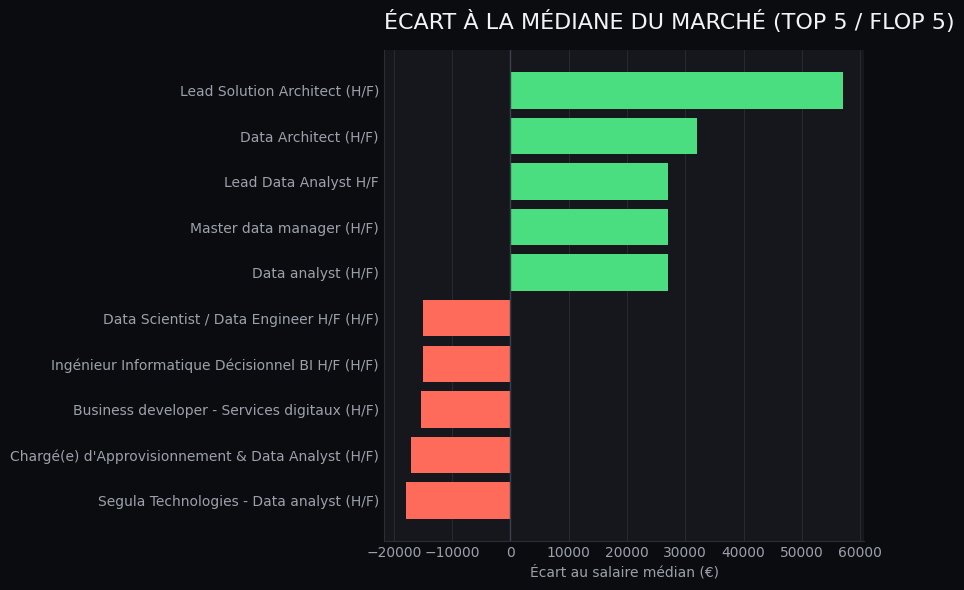

In [41]:
import pandas

df_ecart = con.execute("""
select
    offre_id,
    intitule,
    (salaire_min - median(salaire_min) over ()) as ecart
from fct_offre
where salaire_periode = 'annuel'
    and offre_id != '4933945'
    and offre_id not in ('210KMXZ', '210HNXY', '210KMYJ', '210HNXN')
""").df()

df_extremes = pandas.concat([
    df_ecart.nlargest(5, 'ecart'),
    df_ecart.nsmallest(5, 'ecart')
]).sort_values('ecart')

couleurs_ecart = [MM["green"] if e >= 0 else MM["vermilion"] for e in df_extremes['ecart']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(df_extremes['intitule'], df_extremes['ecart'], color=couleurs_ecart)
ax.axvline(0, color=MM["hairline_bright"], linewidth=1)

ax.set_title("ÉCART À LA MÉDIANE DU MARCHÉ (TOP 5 / FLOP 5)", fontsize=16,
              color=MM["paper"], loc='left', pad=15)
ax.set_xlabel("Écart au salaire médian (€)")
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(MM["hairline"])
ax.tick_params(length=0)
ax.grid(axis='x', color=MM["hairline"], linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Distribution mensuelle des publications d'offres

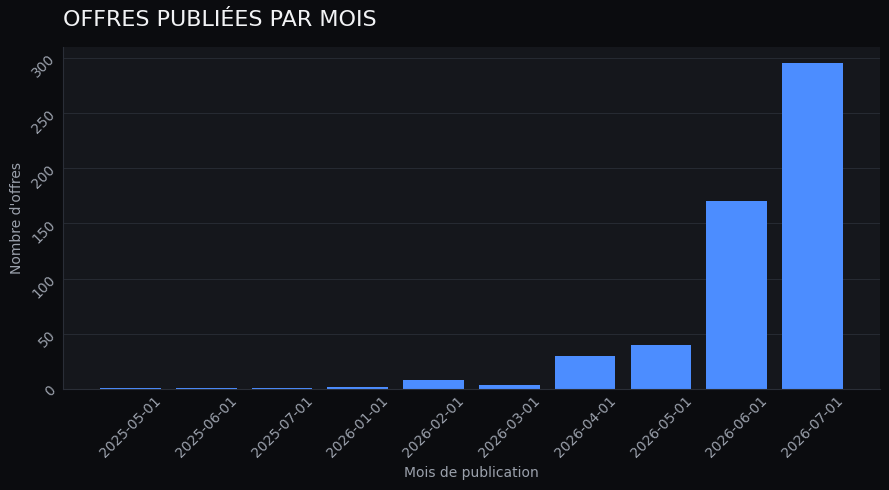

In [42]:
df_mois = con.execute("""
select
    date_trunc('month', date_creation) as mois,
    count(offre_id) as nb_offres
from fct_offre
group by mois
order by mois
""").df()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(df_mois['mois'].astype(str), df_mois['nb_offres'], color=MM["blue"])

ax.set_title("OFFRES PUBLIÉES PAR MOIS", fontsize=16,
              color=MM["paper"], loc='left', pad=15)
ax.set_xlabel("Mois de publication")
ax.set_ylabel("Nombre d'offres")
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(MM["hairline"])
ax.tick_params(length=0, rotation=45)
ax.grid(axis='y', color=MM["hairline"], linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [52]:
con.execute("""
select
    c.nom_commune,
    count(distinct o.offre_id) as nb_offres
from fct_offre o
left join dim_commune c on c.code_postal = o.code_postal
where c.nom_commune is not null
group by c.nom_commune
order by nb_offres desc
limit 10
""").df()

,nom_commune,nb_offres
0,Paris,43
1,Lyon,17
2,Courbevoie,15
3,Toulouse,15
4,Nantes,14
5,Lille,14
6,Nanterre,13
7,Beauzelle,11
8,Bordeaux,10
9,Puteaux,8
